In [3]:
import sqlite3
import pandas as pd

# Path to the symm SQLite database.
DB_PATH = "/Users/theapemachine/data/symm.sqlite"

def connect(db_path: str) -> sqlite3.Connection:
    # symm writes to this WAL-mode database while we read. Read-only URI
    # mode (?mode=ro) intermittently raises "unable to open database file"
    # because it cannot reconcile shared memory against a live writer.
    # WAL allows concurrent readers, so use a plain connection with a busy
    # timeout that waits out brief writer checkpoints, falling back to
    # read-only only if the plain open is unsupported.
    try:
        conn = sqlite3.connect(db_path, timeout=60)
    except sqlite3.OperationalError:
        conn = sqlite3.connect(f"file:{db_path}?mode=ro", uri=True)
    conn.execute("PRAGMA busy_timeout=60000")
    return conn


In [4]:
with connect(DB_PATH) as conn:
    tables = pd.read_sql_query(
        "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn
    )
    print("Tables:", list(tables["name"]))

    # Total captured frames (cheap: summed from the maintained counter).
    total = pd.read_sql_query("SELECT COALESCE(SUM(frames),0) AS n FROM captures", conn)
    print(f"Total capture_frames: {int(total['n'].iloc[0]):,}")

    caps = pd.read_sql_query(
        "SELECT id, started_at, ended_at, frames FROM captures ORDER BY id", conn
    )
    display(caps)

    # Overall covered time window (earliest start -> latest activity across
    # captures; ongoing captures have NULL ended_at, so use started_at too).
    span = pd.read_sql_query(
        "SELECT started_at, ended_at FROM captures", conn
    )
    starts = pd.to_datetime(span["started_at"]).dropna()
    ends = pd.to_datetime(span["ended_at"]).dropna()
    if len(starts):
        first_start = starts.min()
        last_end = max(starts.max(), ends.max()) if len(ends) else starts.max()
        print(f"Covered window: {first_start} -> {last_end}  ({last_end - first_start})")


Tables: ['audit_events', 'capture_frames', 'captures', 'position_stoplosses', 'position_trades', 'sqlite_sequence', 'thesis_checkpoints']
Total capture_frames: 195,510,064


,id,started_at,ended_at,frames
0,1,2026-08-22T11:10:35.380852Z,2026-08-22T11:13:18.722997Z,820375
1,2,2026-08-22T12:14:57.153773Z,2026-08-22T13:03:06.237505Z,16891383
2,3,2026-08-22T15:35:43.173603Z,None,64685696
3,4,2026-08-22T19:29:06.235451Z,None,38168704
4,5,2026-08-22T22:07:29.628316Z,None,155392
5,6,2026-08-22T22:48:22.706805Z,2026-08-22T22:49:17.521659Z,273698
6,7,2026-08-22T22:55:28.679088Z,None,9836288
7,8,2026-08-23T01:15:59.081497Z,None,48371072
8,9,2026-08-23T03:00:01.980204Z,None,2365440
9,10,2026-08-23T04:42:25.969266Z,None,13942016


Covered window: 2026-08-22 11:10:35.380852+00:00 -> 2026-08-23 04:42:25.969266+00:00  (0 days 17:31:50.588414)


In [5]:
# --- Analysis configuration -------------------------------------------------
# Which captures to scan.
#   "all"  -> automatically include EVERY capture in the database. This gives
#             the widest possible window: both the earliest and latest data, and
#             it grows on its own as new captures are recorded.
#   [..]   -> an explicit list, e.g. [1, 2, 3] or list(range(3, 9)).
CAPTURE_IDS = "all"
# Optional trim on either side of the capture timeline (by capture id).
#   FIRST_CAPTURE -> drop captures with id < this (raises the start = narrower past).
#   LAST_CAPTURE  -> drop captures with id > this (lowers the end = narrower future).
# Set to None for no trim on that side (widest coverage on that side).
FIRST_CAPTURE = None
LAST_CAPTURE = None
# Downsample: only examine every Nth frame (seq % N == 0). Raise this for the
# multi-10M-frame captures to keep scans fast; 1 = no sampling (slow but exact).
SEQ_STEP = 10
# "Significant up move" threshold, in percent, for the chosen ranking metric.
MIN_UP_PCT = 3.0
# Optional window-size filter (hours). Raw capture spans are often short, so
# leave these as None unless you process a single long/continuous capture.
MIN_WINDOW_H = None
MAX_WINDOW_H = None
TOP_N = 25
# Ranking metric: 'exchange' = Kraken's own 24h change_pct (direct answer to
# "moved up over ~24h"); 'window' = move computed across the captured frames.
RANK_BY = "exchange"
# ---------------------------------------------------------------------------


In [6]:
# Resolve which capture ids to scan: dynamic "all" + optional trims on either side.
if isinstance(CAPTURE_IDS, str) and CAPTURE_IDS.lower() == "all":
    with connect(DB_PATH) as conn:
        ids = [r[0] for r in conn.execute("SELECT id FROM captures ORDER BY id")]
else:
    ids = list(CAPTURE_IDS)

if FIRST_CAPTURE is not None:
    ids = [i for i in ids if i >= FIRST_CAPTURE]
if LAST_CAPTURE is not None:
    ids = [i for i in ids if i <= LAST_CAPTURE]

if not ids:
    raise SystemExit("No captures selected - widen FIRST_CAPTURE/LAST_CAPTURE or set CAPTURE_IDS.")

in_list = ",".join(str(c) for c in ids)
sql = f"""
WITH ticks AS (
  SELECT
    json_extract(CAST(payload AS TEXT), '$.data[0].symbol')     AS sym,
    CAST(json_extract(CAST(payload AS TEXT), '$.data[0].last')  AS REAL) AS last,
    json_extract(CAST(payload AS TEXT), '$.data[0].timestamp')  AS ts,
    CAST(json_extract(CAST(payload AS TEXT), '$.data[0].change_pct') AS REAL) AS chg,
    CAST(json_extract(CAST(payload AS TEXT), '$.data[0].volume')     AS REAL) AS vol,
    CAST(json_extract(CAST(payload AS TEXT), '$.data[0].high')       AS REAL) AS hi,
    CAST(json_extract(CAST(payload AS TEXT), '$.data[0].low')        AS REAL) AS lo
  FROM capture_frames
  WHERE capture_id IN ({in_list})
    AND seq % {SEQ_STEP} = 0
    AND json_extract(CAST(payload AS TEXT), '$.channel') = 'ticker'
),
ranked AS (
  SELECT sym, last, ts, chg, vol, hi, lo,
         MIN(ts) OVER (PARTITION BY sym) AS first_ts,
         MAX(ts) OVER (PARTITION BY sym) AS last_ts
  FROM ticks
)
SELECT
  sym,
  MAX(CASE WHEN ts = first_ts THEN last END) AS first_last,
  MAX(CASE WHEN ts = last_ts  THEN last END) AS last_last,
  MIN(first_ts) AS window_start,
  MAX(last_ts)  AS window_end,
  MAX(CASE WHEN ts = last_ts THEN chg END) AS change_pct_24h,
  MAX(CASE WHEN ts = last_ts THEN vol END) AS last_volume,
  MAX(CASE WHEN ts = last_ts THEN hi  END) AS last_high,
  MAX(CASE WHEN ts = last_ts THEN lo  END) AS last_low
FROM ranked
GROUP BY sym
"""

with connect(DB_PATH) as conn:
    moves = pd.read_sql_query(sql, conn)

print(f"Extracted {len(moves):,} symbols from captures {ids}")
moves.head()


Extracted 596 symbols from captures [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


,sym,first_last,last_last,window_start,window_end,change_pct_24h,last_volume,last_high,last_low
0,0G/USD,0.16300,0.15900,2026-08-22T16:21:27.831085Z,2026-08-23T03:00:09.682098Z,-12.15,7.735949e+05,0.18700,0.14800
1,1INCH/USD,0.09110,0.09010,2026-08-22T11:10:39.497879Z,2026-08-23T05:01:51.855757Z,-7.02,1.087185e+06,0.09690,0.07000
2,2Z/USD,0.05944,0.05468,2026-08-22T11:12:01.826429Z,2026-08-23T04:48:39.806635Z,-11.00,1.326998e+06,0.06199,0.05166
3,A/USD,0.07640,0.07150,2026-08-22T12:15:04.194167Z,2026-08-23T05:02:01.064807Z,-12.05,5.898721e+05,0.08130,0.07100
4,AAVE/USD,125.47000,122.13000,2026-08-22T12:15:05.517638Z,2026-08-23T05:05:08.797568Z,-3.02,4.546763e+04,128.08000,111.49000


In [7]:
moves["window_start"] = pd.to_datetime(moves["window_start"])
moves["window_end"]   = pd.to_datetime(moves["window_end"])
moves["window_hours"] = (moves["window_end"] - moves["window_start"]).dt.total_seconds() / 3600
moves["pct_window"]   = (moves["last_last"] - moves["first_last"]) / moves["first_last"] * 100

rank_col = "change_pct_24h" if RANK_BY == "exchange" else "pct_window"

movers = moves[moves[rank_col] >= MIN_UP_PCT].copy()
if MIN_WINDOW_H is not None:
    movers = movers[movers["window_hours"] >= MIN_WINDOW_H]
if MAX_WINDOW_H is not None:
    movers = movers[movers["window_hours"] <= MAX_WINDOW_H]

movers = movers.sort_values(rank_col, ascending=False).head(TOP_N).reset_index(drop=True)
print(f"{len(movers)} symbols up >= {MIN_UP_PCT}% by {rank_col}")
display(movers)


25 symbols up >= 3.0% by change_pct_24h


,sym,first_last,last_last,window_start,window_end,change_pct_24h,last_volume,last_high,last_low,window_hours,pct_window
0,USDUC/USD,5.902000e-03,6.674000e-03,2026-08-22 11:13:13.701398+00:00,2026-08-23 02:55:56.710605+00:00,32.97,1.603892e+07,8.616000e-03,4.905000e-03,15.711947,13.080312
1,DENT/USD,2.990000e-05,4.030000e-05,2026-08-22 16:44:25.324904+00:00,2026-08-23 05:03:56.173128+00:00,32.13,1.233322e+09,4.840000e-05,2.890000e-05,12.325236,34.782609
2,TRAC/USD,3.025000e-01,4.018000e-01,2026-08-22 12:26:10.347134+00:00,2026-08-23 03:04:24.308661+00:00,27.68,1.356558e+06,4.278000e-01,2.885000e-01,14.637212,32.826446
3,ACA/USD,5.200000e-04,5.600000e-04,2026-08-22 15:37:55.006028+00:00,2026-08-22 19:14:36.809373+00:00,27.27,2.575375e+07,7.000000e-04,4.400000e-04,3.611612,7.692308
4,BABYSHARK/USD,5.755000e-03,7.047000e-03,2026-08-22 11:12:02.807277+00:00,2026-08-23 05:01:55.798249+00:00,26.65,1.450361e+08,8.878000e-03,5.353000e-03,17.831386,22.450043
5,MIR/USD,4.100000e-03,4.330000e-03,2026-08-22 15:49:28.830525+00:00,2026-08-22 17:16:44.462270+00:00,24.78,3.063169e+05,4.350000e-03,3.220000e-03,1.454342,5.609756
6,SHAPE/USD,4.460000e-04,4.510000e-04,2026-08-22 16:33:10.151169+00:00,2026-08-22 20:50:14.754296+00:00,19.31,1.874163e+07,5.440000e-04,3.780000e-04,4.284612,1.121076
7,PORTAL/USD,1.279000e-02,1.339000e-02,2026-08-22 12:15:11.601183+00:00,2026-08-23 04:50:47.577583+00:00,14.84,1.449562e+07,1.449000e-02,1.008000e-02,16.593327,4.691165
8,PUPS/USD,3.090000e-03,3.090000e-03,2026-08-22 20:51:59.545771+00:00,2026-08-22 20:51:59.545771+00:00,14.40,4.005402e+06,3.568000e-03,2.621000e-03,0.000000,0.000000
9,PUMP/USD,4.505000e-03,4.755000e-03,2026-08-22 11:11:07.251631+00:00,2026-08-23 05:05:14.605352+00:00,9.99,2.658023e+09,5.144000e-03,3.549000e-03,17.902043,5.549390


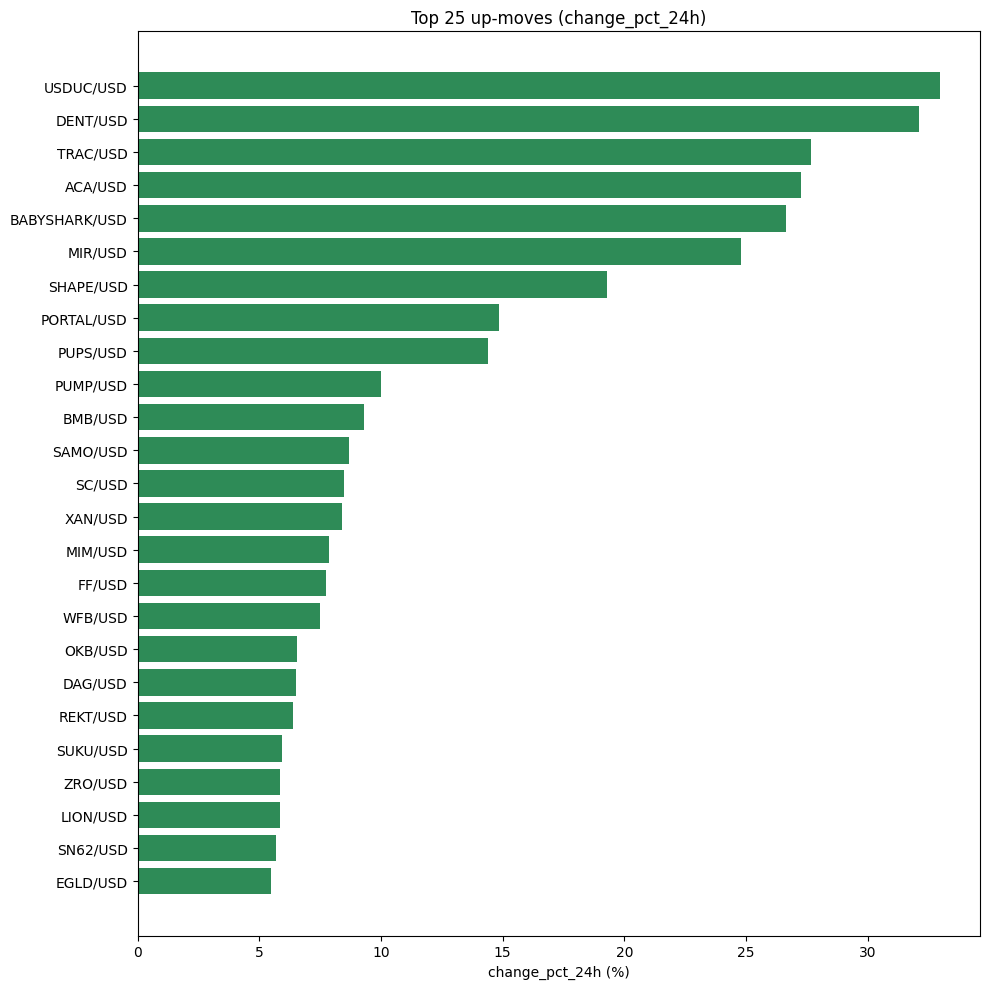

In [8]:
try:
    import matplotlib.pyplot as plt
    plot_df = movers.sort_values(rank_col).tail(TOP_N)
    plt.figure(figsize=(10, max(4, len(plot_df) * 0.4)))
    plt.barh(plot_df["sym"], plot_df[rank_col], color="seagreen")
    plt.xlabel(f"{rank_col} (%)")
    plt.title(f"Top {len(plot_df)} up-moves ({rank_col})")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("matplotlib unavailable:", e)


# Pump / extreme-move event analysis

This section extends the existing Kraken mover screen into a persistent event
detector and full-resolution trade-flow microscope.

It is designed to:

- preserve transient rolling-24h threshold crossings after a coin retraces;
- identify repeated +25%, +50%, +75%, +100%, +150%, +200% and +300% crossings;
- pull exact trade frames around an event rather than using global `seq % N`
  downsampling;
- measure short-horizon trade count, notional flow, buy/sell imbalance, return
  velocity and acceleration;
- compare each observation against a strictly historical trailing baseline;
- provide a reusable event-inspection function for DENT/USD and other risers.


In [9]:
# --- Event-analysis helpers -------------------------------------------------

import json
import numpy as np
import pandas as pd


def selected_capture_ids(conn, first=None, last=None):
    """Return selected capture IDs in ascending order."""
    ids = [
        row[0]
        for row in conn.execute(
            "SELECT id FROM captures ORDER BY id"
        )
    ]

    if first is not None:
        ids = [x for x in ids if x >= first]

    if last is not None:
        ids = [x for x in ids if x <= last]

    return ids


def placeholders(values):
    return ",".join("?" for _ in values)


In [10]:
# --- Exact ticker observations for displaced assets ------------------------

def load_extreme_tickers(
    conn,
    capture_ids,
    floor_pct=20.0,
):
    """
    Load every ticker observation already showing meaningful rolling-24h
    displacement.

    This intentionally does NOT apply seq-based downsampling. The WHERE clause
    keeps the result manageable by retaining only ticker frames at or above
    `floor_pct`.
    """
    if not capture_ids:
        return pd.DataFrame()

    marks = placeholders(capture_ids)

    sql = f"""
    SELECT
        capture_id,
        seq,
        received_at,
        json_extract(
            CAST(payload AS TEXT),
            '$.data[0].symbol'
        ) AS symbol,
        CAST(json_extract(
            CAST(payload AS TEXT),
            '$.data[0].last'
        ) AS REAL) AS price,
        CAST(json_extract(
            CAST(payload AS TEXT),
            '$.data[0].change_pct'
        ) AS REAL) AS change_24h,
        CAST(json_extract(
            CAST(payload AS TEXT),
            '$.data[0].volume'
        ) AS REAL) AS volume_24h,
        CAST(json_extract(
            CAST(payload AS TEXT),
            '$.data[0].high'
        ) AS REAL) AS high_24h,
        CAST(json_extract(
            CAST(payload AS TEXT),
            '$.data[0].low'
        ) AS REAL) AS low_24h
    FROM capture_frames
    WHERE capture_id IN ({marks})
      AND endpoint = 'public'
      AND json_extract(
            CAST(payload AS TEXT),
            '$.channel'
          ) = 'ticker'
      AND CAST(json_extract(
            CAST(payload AS TEXT),
            '$.data[0].change_pct'
          ) AS REAL) >= ?
    ORDER BY received_at, seq
    """

    df = pd.read_sql_query(
        sql,
        conn,
        params=[*capture_ids, floor_pct],
    )

    if df.empty:
        return df

    df["ts"] = pd.to_datetime(df["received_at"], utc=True)

    return (
        df.dropna(subset=["symbol", "price", "change_24h"])
          .sort_values(["symbol", "ts", "seq"])
          .reset_index(drop=True)
    )


In [11]:
# --- Persistent threshold crossing events ----------------------------------

def detect_threshold_crossings(
    ticks,
    thresholds=(25, 50, 75, 100, 150, 200, 300),
):
    """
    Return every upward crossing of each threshold.

    If a coin falls below a threshold and later crosses it again, the new crossing
    is retained. This is useful for identifying multi-wave events.
    """
    if ticks.empty:
        return pd.DataFrame()

    ticks = ticks.sort_values(["symbol", "ts", "seq"]).copy()
    events = []

    for symbol, g in ticks.groupby("symbol", sort=False):
        g = g.reset_index(drop=True)
        previous = None

        for row in g.itertuples():
            current = float(row.change_24h)

            for threshold in thresholds:
                crossed = (
                    current >= threshold
                    and (previous is None or previous < threshold)
                )

                if crossed:
                    events.append({
                        "symbol": symbol,
                        "threshold": float(threshold),
                        "crossed_at": row.ts,
                        "capture_id": row.capture_id,
                        "seq": row.seq,
                        "price": row.price,
                        "change_24h": current,
                        "volume_24h": row.volume_24h,
                        "high_24h": row.high_24h,
                        "low_24h": row.low_24h,
                    })

            previous = current

    return pd.DataFrame(events)


with connect(DB_PATH) as conn:
    EVENT_CAPTURE_IDS = selected_capture_ids(
        conn,
        FIRST_CAPTURE,
        LAST_CAPTURE,
    )

    extreme = load_extreme_tickers(
        conn,
        EVENT_CAPTURE_IDS,
        floor_pct=20.0,
    )

crossings = detect_threshold_crossings(extreme)

print(
    f"Loaded {len(extreme):,} displaced ticker observations "
    f"across {len(EVENT_CAPTURE_IDS):,} captures"
)

if len(crossings):
    display(
        crossings.sort_values(
            ["crossed_at", "symbol", "threshold"]
        ).reset_index(drop=True)
    )
else:
    print("No threshold crossings found.")


Loaded 22,359 displaced ticker observations across 10 captures


,symbol,threshold,crossed_at,capture_id,seq,price,change_24h,volume_24h,high_24h,low_24h
0,SAMO/USD,25.0,2026-08-22 11:10:41.526351+00:00,1,757,0.000345,28.73,1.981944e+07,0.000371,0.000267
1,LCX/USD,25.0,2026-08-22 11:10:41.528165+00:00,1,793,0.034810,125.45,1.386102e+07,0.040630,0.015340
2,LCX/USD,50.0,2026-08-22 11:10:41.528165+00:00,1,793,0.034810,125.45,1.386102e+07,0.040630,0.015340
3,LCX/USD,75.0,2026-08-22 11:10:41.528165+00:00,1,793,0.034810,125.45,1.386102e+07,0.040630,0.015340
4,LCX/USD,100.0,2026-08-22 11:10:41.528165+00:00,1,793,0.034810,125.45,1.386102e+07,0.040630,0.015340
...,...,...,...,...,...,...,...,...,...,...
308,BABYSHARK/USD,25.0,2026-08-23 02:57:57.737120+00:00,8,47904819,0.007088,25.96,1.325181e+08,0.008878,0.005353
309,BABYSHARK/USD,25.0,2026-08-23 03:01:19.517779+00:00,9,498220,0.007040,25.11,1.353659e+08,0.008878,0.005353
310,BMB/USD,25.0,2026-08-23 04:42:45.143676+00:00,10,51004,0.002807,25.09,1.350985e+06,0.003500,0.002142
311,BABYSHARK/USD,25.0,2026-08-23 04:42:45.144350+00:00,10,51048,0.007229,29.92,1.447200e+08,0.008878,0.005353


In [12]:
# --- 100%+ event history ----------------------------------------------------

if len(crossings):
    hundred_plus = (
        crossings[crossings["threshold"] >= 100]
        .sort_values(["crossed_at", "symbol", "threshold"])
        .reset_index(drop=True)
    )

    print(f"{len(hundred_plus):,} recorded 100%+ threshold crossings")
    display(hundred_plus)
else:
    hundred_plus = pd.DataFrame()


14 recorded 100%+ threshold crossings


,symbol,threshold,crossed_at,capture_id,seq,price,change_24h,volume_24h,high_24h,low_24h
0,LCX/USD,100.0,2026-08-22 11:10:41.528165+00:00,1,793,0.034810,125.45,1.386102e+07,0.040630,0.01534
1,NOCK/USD,100.0,2026-08-22 12:55:07.979237+00:00,2,13818304,0.040000,158.06,2.469016e+06,0.040000,0.01550
2,NOCK/USD,150.0,2026-08-22 12:55:07.979237+00:00,2,13818304,0.040000,158.06,2.469016e+06,0.040000,0.01550
3,LCX/USD,100.0,2026-08-22 15:43:10.720339+00:00,3,3369452,0.033320,101.45,1.786520e+07,0.040630,0.01615
4,LCX/USD,100.0,2026-08-22 15:48:03.286357+00:00,3,5356614,0.032940,100.61,1.769402e+07,0.040630,0.01615
5,LCX/USD,100.0,2026-08-22 15:57:23.561737+00:00,3,9467308,0.032390,100.31,1.771348e+07,0.040630,0.01615
6,HPOS10I/USD,100.0,2026-08-22 16:00:20.978420+00:00,3,10666567,0.033990,100.65,1.079144e+05,0.033990,0.01693
7,LCX/USD,100.0,2026-08-22 16:03:12.206268+00:00,3,12129090,0.033180,101.58,1.779627e+07,0.040630,0.01629
8,LCX/USD,100.0,2026-08-22 16:05:46.107713+00:00,3,13367089,0.032960,102.33,1.779241e+07,0.040630,0.01629
9,LCX/USD,100.0,2026-08-22 16:13:52.675924+00:00,3,16870227,0.033350,102.24,1.781938e+07,0.040630,0.01643


In [13]:
# --- Episode summaries ------------------------------------------------------

def summarize_episode(ticks, symbol):
    """Summarize all retained displaced ticker observations for one symbol."""
    g = (
        ticks[ticks["symbol"] == symbol]
        .sort_values(["ts", "seq"])
        .copy()
    )

    if g.empty:
        return None

    peak_i = g["change_24h"].idxmax()
    peak = g.loc[peak_i]
    latest = g.iloc[-1]

    first_100 = g[g["change_24h"] >= 100]
    first_100_at = (
        first_100.iloc[0]["ts"]
        if not first_100.empty
        else pd.NaT
    )

    return {
        "symbol": symbol,
        "first_seen": g.iloc[0]["ts"],
        "first_100_at": first_100_at,
        "peak_at": peak["ts"],
        "peak_change_24h": peak["change_24h"],
        "peak_price": peak["price"],
        "latest_at": latest["ts"],
        "latest_change_24h": latest["change_24h"],
        "latest_price": latest["price"],
        "retracement_from_peak_pct_points":
            peak["change_24h"] - latest["change_24h"],
        "observations": len(g),
    }


dent_episode = summarize_episode(extreme, "DENT/USD")
dent_episode


{'symbol': 'DENT/USD',
 'first_seen': Timestamp('2026-08-22 22:07:51.367537+0000', tz='UTC'),
 'first_100_at': NaT,
 'peak_at': Timestamp('2026-08-23 04:43:07.879791+0000', tz='UTC'),
 'peak_change_24h': np.float64(34.55),
 'peak_price': np.float64(4.05e-05),
 'latest_at': Timestamp('2026-08-23 05:04:27.184650+0000', tz='UTC'),
 'latest_change_24h': np.float64(32.79),
 'latest_price': np.float64(4.05e-05),
 'retracement_from_peak_pct_points': np.float64(1.759999999999998),
 'observations': 33}

In [14]:
# --- Raw trade loader -------------------------------------------------------

def load_trades(
    conn,
    capture_ids,
    symbol,
    start,
    end,
):
    """
    Load full-resolution public trade updates for one symbol and time range.
    """
    if not capture_ids:
        return pd.DataFrame()

    marks = placeholders(capture_ids)

    sql = f"""
    SELECT
        capture_id,
        seq,
        received_at,
        CAST(payload AS TEXT) AS payload
    FROM capture_frames
    WHERE capture_id IN ({marks})
      AND endpoint = 'public'
      AND received_at >= ?
      AND received_at <= ?
      AND json_extract(
            CAST(payload AS TEXT),
            '$.channel'
          ) = 'trade'
    ORDER BY received_at, seq
    """

    params = [
        *capture_ids,
        pd.Timestamp(start).isoformat(),
        pd.Timestamp(end).isoformat(),
    ]

    rows = conn.execute(sql, params)
    out = []

    for capture_id, seq, received_at, payload in rows:
        frame = json.loads(payload)

        if frame.get("type") != "update":
            continue

        for trade in frame.get("data", []):
            if trade.get("symbol") != symbol:
                continue

            try:
                price = float(trade["price"])
                qty = float(trade["qty"])
            except (KeyError, TypeError, ValueError):
                continue

            if price <= 0 or qty <= 0:
                continue

            ts = pd.to_datetime(
                trade.get("timestamp", received_at),
                utc=True,
            )

            out.append({
                "capture_id": capture_id,
                "seq": seq,
                "ts": ts,
                "side": trade.get("side"),
                "price": price,
                "qty": qty,
                "notional": price * qty,
            })

    if not out:
        return pd.DataFrame(
            columns=[
                "capture_id",
                "seq",
                "ts",
                "side",
                "price",
                "qty",
                "notional",
            ]
        )

    return (
        pd.DataFrame(out)
        .sort_values(["ts", "seq"])
        .reset_index(drop=True)
    )


In [15]:
# --- Short-horizon trade bars ----------------------------------------------

def trade_bars(trades, freq="10s"):
    """
    Aggregate raw trade prints into short bars.

    buy_imbalance =
        (buy_notional - sell_notional) /
        (buy_notional + sell_notional)
    """
    if trades.empty:
        return pd.DataFrame()

    x = trades.copy()

    x["buy_notional"] = np.where(
        x["side"].eq("buy"),
        x["notional"],
        0.0,
    )

    x["sell_notional"] = np.where(
        x["side"].eq("sell"),
        x["notional"],
        0.0,
    )

    bars = (
        x.set_index("ts")
        .resample(freq)
        .agg(
            price_open=("price", "first"),
            price_high=("price", "max"),
            price_low=("price", "min"),
            price_close=("price", "last"),
            trades=("price", "size"),
            qty=("qty", "sum"),
            notional=("notional", "sum"),
            buy_notional=("buy_notional", "sum"),
            sell_notional=("sell_notional", "sum"),
        )
    )

    bars["price_close"] = bars["price_close"].ffill()

    for col in ["price_open", "price_high", "price_low"]:
        bars[col] = bars[col].fillna(bars["price_close"])

    total = bars["buy_notional"] + bars["sell_notional"]

    bars["buy_imbalance"] = (
        (bars["buy_notional"] - bars["sell_notional"])
        / total.replace(0, np.nan)
    )

    bars["ret_10s"] = bars["price_close"].pct_change()
    bars["ret_1m"] = bars["price_close"].pct_change(6)
    bars["ret_5m"] = bars["price_close"].pct_change(30)

    return bars


In [16]:
# --- Strictly backward-looking anomaly features ----------------------------

def trailing_zscore(series, window):
    """
    Z-score against a trailing baseline that excludes the current observation.
    """
    baseline = series.shift(1)
    min_periods = max(10, window // 5)

    mean = baseline.rolling(
        window,
        min_periods=min_periods,
    ).mean()

    std = baseline.rolling(
        window,
        min_periods=min_periods,
    ).std()

    return (series - mean) / std.replace(0, np.nan)


def add_pump_features(bars, baseline_bars=180):
    """
    Add candidate ignition features.

    baseline_bars=180 corresponds to 30 minutes for 10-second bars.
    """
    if bars.empty:
        return bars.copy()

    x = bars.copy()

    x["trade_count_z"] = trailing_zscore(
        np.log1p(x["trades"]),
        baseline_bars,
    )

    x["notional_z"] = trailing_zscore(
        np.log1p(x["notional"]),
        baseline_bars,
    )

    x["abs_return_z"] = trailing_zscore(
        x["ret_10s"].abs(),
        baseline_bars,
    )

    x["ret_1m_accel"] = (
        x["ret_1m"] - x["ret_1m"].shift(6)
    )

    x["buy_imbalance_1m"] = (
        x["buy_imbalance"]
        .rolling(6, min_periods=1)
        .mean()
    )

    x["flow_price_divergence"] = (
        x["buy_imbalance_1m"]
        - np.sign(x["ret_1m"].fillna(0))
    )

    return x


In [17]:
# --- Event selection --------------------------------------------------------

def first_crossing(crossings, symbol, threshold=100):
    if crossings.empty:
        return None

    found = (
        crossings[
            (crossings["symbol"] == symbol)
            & (crossings["threshold"] == threshold)
        ]
        .sort_values("crossed_at")
    )

    if found.empty:
        return None

    return found.iloc[0]


In [18]:
# --- DENT microscope around first +100% crossing ---------------------------

dent_100 = first_crossing(crossings, "DENT/USD", 100)

if dent_100 is None:
    print("No DENT/USD +100% crossing is present in the selected captures.")
    dent_trades = pd.DataFrame()
    dent_bars = pd.DataFrame()
else:
    event_at = dent_100["crossed_at"]

    with connect(DB_PATH) as conn:
        dent_trades = load_trades(
            conn,
            EVENT_CAPTURE_IDS,
            "DENT/USD",
            event_at - pd.Timedelta(hours=3),
            event_at + pd.Timedelta(hours=1),
        )

    dent_bars = add_pump_features(
        trade_bars(dent_trades, "10s")
    )

    print(
        f"DENT first +100% crossing: {event_at}\n"
        f"Raw trades loaded: {len(dent_trades):,}\n"
        f"10-second bars: {len(dent_bars):,}"
    )

    display(
        dent_bars.loc[
            event_at - pd.Timedelta(minutes=30):
            event_at + pd.Timedelta(minutes=10)
        ].tail(250)
    )


No DENT/USD +100% crossing is present in the selected captures.


In [19]:
# --- DENT plots -------------------------------------------------------------

if not dent_bars.empty:
    import matplotlib.pyplot as plt

    view_start = event_at - pd.Timedelta(minutes=30)
    view_end = event_at + pd.Timedelta(minutes=10)
    view = dent_bars.loc[view_start:view_end]

    plt.figure(figsize=(12, 5))
    plt.plot(view.index, view["price_close"])
    plt.axvline(event_at, linestyle="--")
    plt.ylabel("DENT/USD")
    plt.xlabel("Time")
    plt.title("DENT/USD around first +100% rolling-24h crossing")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.plot(view.index, view["notional_z"], label="Notional z-score")
    plt.plot(view.index, view["trade_count_z"], label="Trade-count z-score")
    plt.axvline(event_at, linestyle="--")
    plt.axhline(0, linewidth=1)
    plt.ylabel("Trailing anomaly z-score")
    plt.xlabel("Time")
    plt.title("DENT trade-flow anomalies")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.plot(view.index, view["buy_imbalance_1m"])
    plt.axvline(event_at, linestyle="--")
    plt.axhline(0, linewidth=1)
    plt.ylabel("1-minute buy imbalance")
    plt.xlabel("Time")
    plt.title("DENT directional trade-flow imbalance")
    plt.tight_layout()
    plt.show()


In [20]:
# --- Generic event microscope ----------------------------------------------

def inspect_event(
    symbol,
    threshold=100,
    before="3h",
    after="1h",
    bar_freq="10s",
    baseline_bars=180,
):
    """
    Return the event row, raw trades and derived bars/features around the first
    requested threshold crossing.
    """
    hit = first_crossing(crossings, symbol, threshold)

    if hit is None:
        raise ValueError(
            f"No {symbol} +{threshold}% crossing in selected captures"
        )

    event_at = hit["crossed_at"]

    with connect(DB_PATH) as conn:
        trades = load_trades(
            conn,
            EVENT_CAPTURE_IDS,
            symbol,
            event_at - pd.Timedelta(before),
            event_at + pd.Timedelta(after),
        )

    bars = trade_bars(trades, bar_freq)
    features = add_pump_features(
        bars,
        baseline_bars=baseline_bars,
    )

    return {
        "event": hit,
        "trades": trades,
        "bars": features,
    }


# Examples:
# dent = inspect_event("DENT/USD", 100)
# trump = inspect_event("TRUMP/USD", 100)
# melania = inspect_event("MELANIA/USD", 100)


## Next extension: L2/L3 microstructure

The notebook now produces a precise event timestamp and a full-resolution
trade-flow window. The next analysis layer can use those same windows to inspect
captured book and L3 messages for:

- visible bid/ask depth and imbalance;
- ask depletion rate;
- replenishment after aggressive buys;
- cancellation bursts;
- repeated or mirrored order sizes;
- queue concentration;
- order-arrival intensity;
- price impact per unit notional;
- book behavior before the first obvious price acceleration.

That layer should be built against the exact JSON shape of the stored Kraken
book/L3 payloads so it stays faithful to the raw capture.
